# Direct multi-step — 4 model DEFAULt + naive52

Mốc đứng dự báo: **2012-08-17** (tuần cuối train). Mỗi thuật toán train **10 model**, model `t+h`
dự báo tuần `2012-08-17 + h tuần` → phủ trọn 10 tuần của `val_set` (2012-08-24 → 2012-10-26).

Đánh giá trên 2 tập cv và val

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import AdaBoostRegressor, RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

HZ, NS, HOL_W = 10, 5, 5.0        # 10 horizon | 5 fold | tuần lễ nặng gấp 5 khi tính WMAE
W = lambda n: pd.Timedelta(weeks=n)
METRICS = ("mae", "rmse", "wape", "wmae")


def sc(t, p, hol):
    """4 chỉ số dùng chung. `hol` = cờ IsHoliday của TUẦN ĐÍCH (cột hol_t)."""
    t, p = np.asarray(t, float), np.asarray(p, float)
    w = np.where(np.asarray(hol, bool), HOL_W, 1.0)
    e = np.abs(t - p)
    return dict(mae=e.mean(), rmse=root_mean_squared_error(t, p),
                wape=e.sum() / np.abs(t).sum(), wmae=(w * e).sum() / w.sum())


def get_file_path(filename):
    for root in [Path.cwd()] + list(Path.cwd().parents):
        for f in root.rglob(filename):
            if f.is_file():
                return f
    raise FileNotFoundError(f"Không tìm thấy file {filename}!")


train, val, test = (pd.read_csv(get_file_path(f), parse_dates=["Date"])
                    for f in ("train_final.csv", "val_set.csv", "test_final.csv"))

# Ghép train+val thành 1 dòng thời gian liên tục rồi mới shift -> nhãn không đứt ở ranh giới
panel = pd.concat([train, val]).sort_values(["Store", "Date"]).reset_index(drop=True)
for h in range(1, HZ + 1):
    panel[f"y{h}"] = panel.groupby("Store")["Weekly_Sales"].shift(-h)

dates = pd.DatetimeIndex(sorted(train["Date"].unique()))
T     = dates[-1]                                      # 2012-08-17 — mốc đứng dự báo
cal   = pd.concat([train, val, test]).drop_duplicates("Date").set_index("Date")["IsHoliday"].astype(int)
lag52 = panel.set_index(["Store", "Date"])["Lag_52"]   # để chấm naive52 tại tuần đích
FEAT  = [c for c in train.columns if c not in ("Date", "Weekly_Sales", "Type")] + ["hol_t", "woy_t", "mon_t"]

print(f"train {train.shape} {dates[0].date()} -> {T.date()} ({len(dates)} tuần)"
      f" | val {val.shape} {val.Date.min().date()} -> {val.Date.max().date()} ({val.Date.nunique()} tuần)")
print(f"{len(FEAT)} feature | mốc đứng {T.date()} -> tuần đích t+1 {(T + W(1)).date()}, t+10 {(T + W(10)).date()}")

train (3645, 24) 2011-02-04 -> 2012-08-17 (81 tuần) | val (450, 24) 2012-08-24 -> 2012-10-26 (10 tuần)
24 feature | mốc đứng 2012-08-17 -> tuần đích t+1 2012-08-24, t+10 2012-10-26


In [3]:
def block(h, origins):
    """Hàng của model h: feature tại tuần gốc + lịch tuần đích (lịch biết trước, không leakage)."""
    d = panel[panel["Date"].isin(pd.DatetimeIndex(origins)) & panel[f"y{h}"].notna()].copy()
    t = d["Date"] + W(h)
    d["hol_t"], d["woy_t"], d["mon_t"] = t.map(cal), t.dt.isocalendar().week.astype(int), t.dt.month
    d["target_Date"] = t
    d["naive52"] = lag52.reindex(pd.MultiIndex.from_arrays([d["Store"], t])).to_numpy()
    return d.reset_index(drop=True)


# Expanding window: split trên MẢNG NGÀY, không phải trên dòng (dữ liệu là panel 45 store/tuần)
folds = [(dates[a], dates[b]) for a, b in TimeSeriesSplit(n_splits=NS, test_size=HZ).split(dates)]
assert all(tr.max() < te.min() and te.max() <= T for tr, te in folds)


def cv_split(d):
    """(train_idx, test_idx) theo vị trí hàng trong d — nhãn tập train luôn <= mốc cắt của fold."""
    out = []
    for tr_d, te_d in folds:
        cut = tr_d[-1]
        a = np.where(d["Date"].isin(tr_d) & (d["target_Date"] <= cut))[0]
        org = pd.DatetimeIndex([cut]).append(te_d[:-1])
        b = np.where(d["Date"].isin(org) & d["target_Date"].isin(te_d))[0]
        out.append((a, b))
    return out


for i, (tr_d, te_d) in enumerate(folds, 1):
    print(f"fold {i}: train {tr_d[0].date()} -> {tr_d[-1].date()} ({len(tr_d)} tuần)"
          f" | test {te_d[0].date()} -> {te_d[-1].date()}")

fold 1: train 2011-02-04 -> 2011-09-02 (31 tuần) | test 2011-09-09 -> 2011-11-11
fold 2: train 2011-02-04 -> 2011-11-11 (41 tuần) | test 2011-11-18 -> 2012-01-20
fold 3: train 2011-02-04 -> 2012-01-20 (51 tuần) | test 2012-01-27 -> 2012-03-30
fold 4: train 2011-02-04 -> 2012-03-30 (61 tuần) | test 2012-04-06 -> 2012-06-08
fold 5: train 2011-02-04 -> 2012-06-08 (71 tuần) | test 2012-06-15 -> 2012-08-17


In [4]:
RF_PARAMS  = dict(n_estimators=200, max_depth=12, min_samples_split=5, min_samples_leaf=2,
                  n_jobs=-1, random_state=42)
DT_PARAMS  = dict(max_depth=12, min_samples_split=5, min_samples_leaf=2, random_state=42)
ADA_PARAMS = dict(n_estimators=200, random_state=42)
XGB_PARAMS = dict(n_estimators=400, max_depth=6, learning_rate=0.05, subsample=0.9,
                  colsample_bytree=0.9, tree_method="hist", n_jobs=-1, random_state=42)

KEEP = ["Store", "target_Date", "hol_t"]
CVP, PREDS = {}, {}       # bảng dự đoán thô: CV trên train, và val — metric tính lại từ đây


def run_10(name, Model=None, params=None):
    """Train 10 model direct cho 1 thuật toán. Model=None -> baseline naive52 (Lag_52 tuần đích)."""
    models, ps, cs = [], [], []
    for h in range(1, HZ + 1):
        d = block(h, dates)
        fit, va = d[d.target_Date <= T].reset_index(drop=True), d[d.Date == T]
        y = f"y{h}"
        for i, (a, b) in enumerate(cv_split(fit), 1):
            pb = (fit.loc[b, "naive52"].to_numpy() if Model is None else
                  Model(**params).fit(fit.loc[a, FEAT], fit.loc[a, y]).predict(fit.loc[b, FEAT]))
            cs.append(fit.loc[b, KEEP].assign(model=name, horizon=h, fold=i,
                                              y_true=fit.loc[b, y], y_pred=pb))
        if Model is None:
            pred = va["naive52"].to_numpy()
        else:
            m = Model(**params).fit(fit[FEAT], fit[y])
            models.append(m)
            pred = m.predict(va[FEAT])
        ps.append(va[KEEP].assign(model=name, horizon=h, y_true=va[y], y_pred=pred))
    CVP[name], PREDS[name] = pd.concat(cs, ignore_index=True), pd.concat(ps, ignore_index=True)
    print(f"{name:8s} xong — CV {len(CVP[name]):6,d} dòng | val {len(PREDS[name])} dòng")
    return models


rf_models      = run_10("rf",  RandomForestRegressor, RF_PARAMS)
dt_models      = run_10("dt",  DecisionTreeRegressor, DT_PARAMS)
ada_models     = run_10("ada", AdaBoostRegressor,     ADA_PARAMS)
xgboost_models = run_10("xgb", XGBRegressor,          XGB_PARAMS)
run_10("naive52")

assert all(len(m) == HZ for m in (rf_models, dt_models, ada_models, xgboost_models))
assert all(len(p) == 450 for p in PREDS.values())
print("\nrf_models[0] = model t+1 ... rf_models[9] = model t+10 (dt_models / ada_models / xgboost_models tương tự)")

rf       xong — CV 12,375 dòng | val 450 dòng
dt       xong — CV 12,375 dòng | val 450 dòng
ada      xong — CV 12,375 dòng | val 450 dòng
xgb      xong — CV 12,375 dòng | val 450 dòng
naive52  xong — CV 12,375 dòng | val 450 dòng

rf_models[0] = model t+1 ... rf_models[9] = model t+10 (dt_models / ada_models / xgboost_models tương tự)


### Về WMAE

Metric tính **gộp thẳng từ bảng dự đoán**, không phải trung bình theo horizon. Lý do: trong một
horizon, cả 45 dòng đều rơi vào **cùng một tuần đích** nên trọng số ngày lễ đồng đều — WMAE khi đó
thoái hoá thành đúng MAE. WMAE chỉ nói lên điều gì khi gộp nhiều tuần đích, tức ở bảng `overall`
(10 tuần, trong đó `2012-09-07` là tuần lễ) và ở các fold CV.

Nên trong `results` (chi tiết theo horizon) cột `val_wmae` sẽ **bằng** `val_mae` — đó là tính chất
của dữ liệu, không phải lỗi.

In [5]:
ORDER = ["rf", "dt", "ada", "xgb", "naive52"]


def agg(df, by, pfx):
    """Gộp sai số từ chính bảng dự đoán thô."""
    return pd.DataFrame({k: sc(g.y_true, g.y_pred, g.hol_t)
                         for k, g in df.groupby(by)}).T.add_prefix(f"{pfx}_")


cvall  = pd.concat(CVP.values(),   ignore_index=True)
valall = pd.concat(PREDS.values(), ignore_index=True)

results = agg(cvall, ["model", "horizon"], "cv").join(agg(valall, ["model", "horizon"], "val")).sort_index()
results.index.names = ["model", "horizon"]
overall = agg(cvall, "model", "cv").join(agg(valall, "model", "val")).loc[ORDER]

assert results.notna().all().all() and len(results) == 50
print(f"results: {results.shape[0]} dòng x {results.shape[1]} cột — index (model, horizon)")
print("Lấy riêng: results.loc['rf'] | results.loc[('xgb', 5)] | results.xs(5, level='horizon')\n")
display(overall.round(4))
display(results.round(4))

results: 50 dòng x 8 cột — index (model, horizon)
Lấy riêng: results.loc['rf'] | results.loc[('xgb', 5)] | results.xs(5, level='horizon')



,cv_mae,cv_rmse,cv_wape,cv_wmae,val_mae,val_rmse,val_wape,val_wmae
rf,105654.2435,189249.0953,0.0998,117148.2936,50093.0641,71267.9697,0.0490,53225.0520
dt,127737.9022,220428.0287,0.1207,139546.0362,65256.5488,93242.4577,0.0639,74053.8328
ada,141850.9394,207617.0317,0.1340,149407.8253,122232.6194,141827.5500,0.1197,116065.8767
xgb,101118.3515,178074.3972,0.0956,114572.2614,44880.0068,62886.8952,0.0439,50918.9748
naive52,58924.3842,82816.9263,0.0557,65222.9478,54159.1089,88280.7533,0.0530,57037.7581


cv_mae      cv_rmse  cv_wape      cv_wmae      val_mae  \
model   horizon                                                                
ada     1        141779.1031  199368.7456   0.1331  166725.2096  113657.8313   
        2        166714.2689  233992.8547   0.1561  186343.3194  109129.6592   
        3        130347.4548  196719.5468   0.1227  132106.5570  100649.0199   
        4        138329.3032  212644.2721   0.1298  141644.9894  130724.5255   
        5        159912.0818  239875.9461   0.1504  152078.8540  139827.7562   
        6        146789.3223  238828.8572   0.1389  137751.6161  150186.0138   
        7        116158.8158  153262.9591   0.1127  109498.4654   97143.5365   
        8        109838.6880  135188.1320   0.1063  109838.6880  112390.7875   
        9        133388.9821  165770.4004   0.1293  133388.9821  126375.0283   
        10       118149.0612  142186.2094   0.1142  118149.0612  142242.0354   
dt      1        108524.1239  179103.6380   0.1018  139039.0105   63100.5119   
        2        166269.8600  276822.7853   0.1557  189278.9929   65637.0357   
        3        128599.7159  218712.7767   0.1211  138093.6518   96047.0430   
        4        126186.8098  209827.9494   0.1184  131488.5323   80556.0378   
        5        153892.7011  297473.8646   0.1448  148756.8623   50142.0771   
        6        127262.9682  222240.0467   0.1204  123435.7560   71031.6454   
        7         95025.4904  139078.3932   0.0922   96332.3786   59834.4829   
        8         96271.7455  135568.4774   0.0932   96271.7455   53119.3165   
        9        100024.4417  138934.7034   0.0970  100024.4417   47698.1024   
        10       103172.1141  148398.8247   0.0997  103172.1141   65399.2349   
naive52 1         60103.9967   86160.2384   0.0564   64084.1351   65802.1736   
        2         59049.2910   83271.0911   0.0553   64451.4066   76209.8062   
        3         59480.4270   83992.5839   0.0560   66063.1687   64234.3809   
        4         59281.0145   82706.2900   0.0556   66604.8726   37939.3842   
        5         59369.7307   83316.6209   0.0559   67760.1895   55537.7467   
        6         60379.5351   84614.2030   0.0571   70077.3415   52256.6544   
        7         59772.8775   83165.5689   0.0580   71592.1698   50922.3549   
        8         53809.7748   73173.0586   0.0521   53809.7748   54840.1238   
        9         53414.3179   71536.4909   0.0518   53414.3179   45999.0424   
        10        52081.4991   69648.0277   0.0503   52081.4991   37849.4222   
rf      1         91192.5190  163610.9600   0.0856  121814.2864   49897.7251   
        2        135544.0246  232190.8617   0.1269  161472.9947   48493.9279   
        3        101668.3823  184133.3773   0.0957  107168.9837   61055.0216   
        4        104961.7780  193415.3277   0.0985  109285.2146   58001.7964   
        5        122158.2689  230805.5627   0.1149  118459.1922   42101.3656   
        6        121113.3135  217398.2806   0.1146  115845.3956   55961.1729   
        7         79003.4750  116767.5374   0.0767   78652.6178   55863.6966   
        8         75706.8557  107609.5656   0.0733   75706.8557   32284.0306   
        9         78586.9631  107459.4573   0.0762   78586.9631   47111.3386   
        10        92257.9025  124581.6262   0.0892   92257.9025   50160.5660   
xgb     1         93696.5050  165936.9735   0.0879  123290.4049   52310.3674   
        2        117973.1161  200599.6297   0.1105  148806.2083   52434.9313   
        3        104936.5256  186729.4117   0.0988  110607.4269   66016.3949   
        4        104825.4591  192215.0274   0.0984  110953.3065   39578.0447   
        5        103869.6859  194664.9807   0.0977  106434.1705   32988.8232   
        6        111096.6223  203276.0201   0.1051  108659.5008   28233.6972   
        7         82957.9631  122218.4779   0.0805   85203.0168   48338.8815   
        8         77102.0976  111968.9683   0.0746   77102.0976   33498.7193   
        9         8107

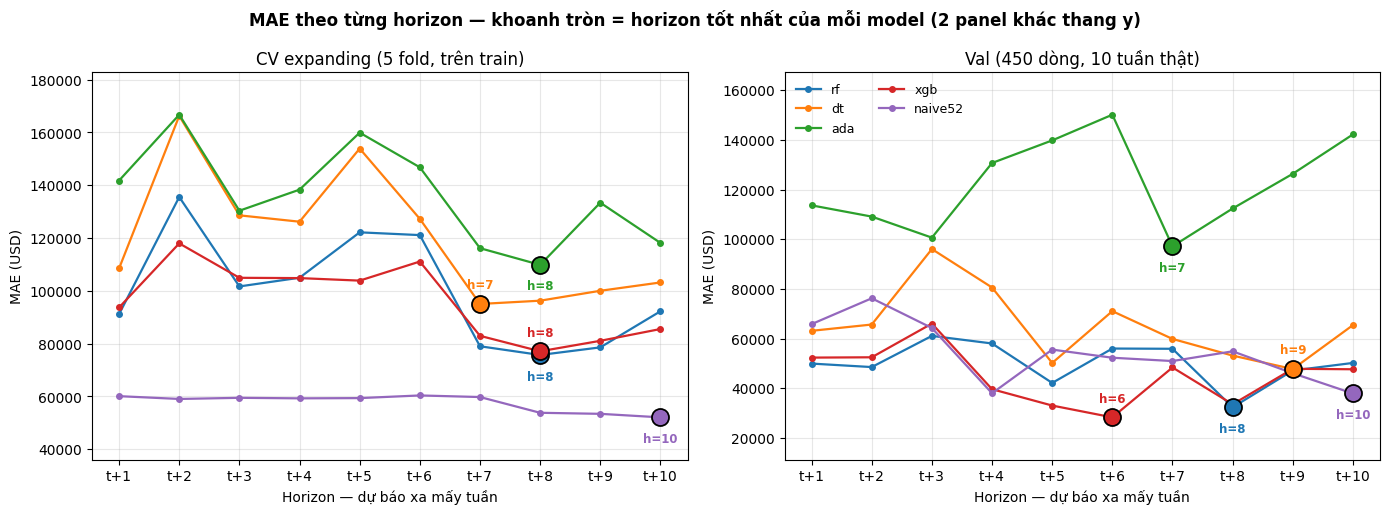

cv                              val                      
        h tốt nhất MAE (USD) % so TB 10h h tốt nhất MAE (USD) % so TB 10h
rf             t+8    75,707      -24.5%        t+8    32,284      -35.6%
dt             t+7    95,025      -21.2%        t+9    47,698      -26.9%
ada            t+8   109,839      -19.3%        t+7    97,144      -20.5%
xgb            t+8    77,102      -19.9%        t+6    28,234      -37.1%
naive52       t+10    52,081       -9.7%       t+10    37,849      -30.1%

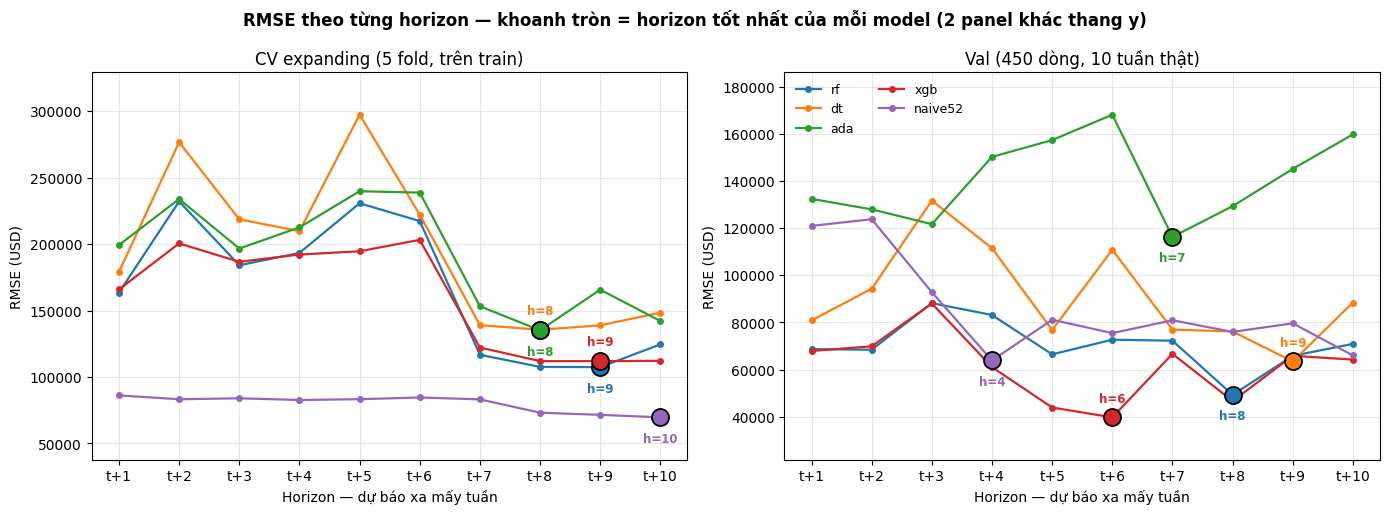

cv                               val                       
        h tốt nhất RMSE (USD) % so TB 10h h tốt nhất RMSE (USD) % so TB 10h
rf             t+9    107,459      -36.0%        t+8     49,285      -30.2%
dt             t+8    135,568      -31.0%        t+9     63,441      -30.4%
ada            t+8    135,188      -29.5%        t+7    116,295      -17.4%
xgb            t+9    111,965      -30.1%        t+6     39,724      -35.3%
naive52       t+10     69,648      -13.1%        t+4     63,853      -25.8%

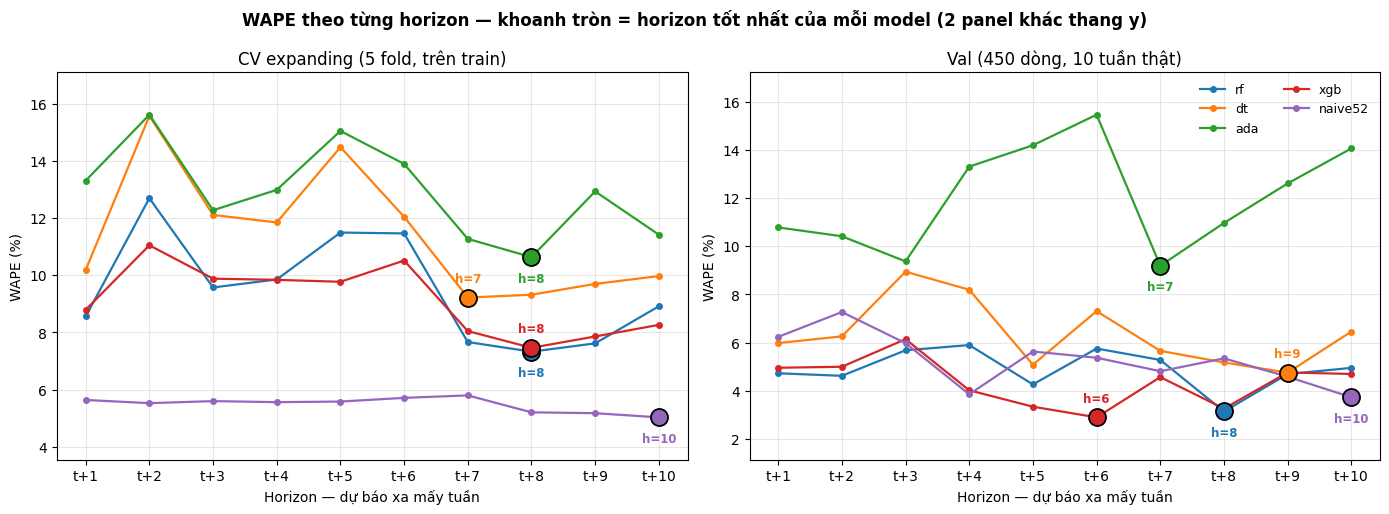

cv                             val                     
        h tốt nhất WAPE (%) % so TB 10h h tốt nhất WAPE (%) % so TB 10h
rf             t+8     7.33      -23.0%        t+8     3.15      -35.8%
dt             t+7     9.22      -19.4%        t+9     4.76      -25.5%
ada            t+8    10.63      -17.8%        t+7     9.19      -23.6%
xgb            t+8     7.46      -18.4%        t+6     2.91      -33.5%
naive52       t+10     5.03       -8.2%       t+10     3.74      -29.3%

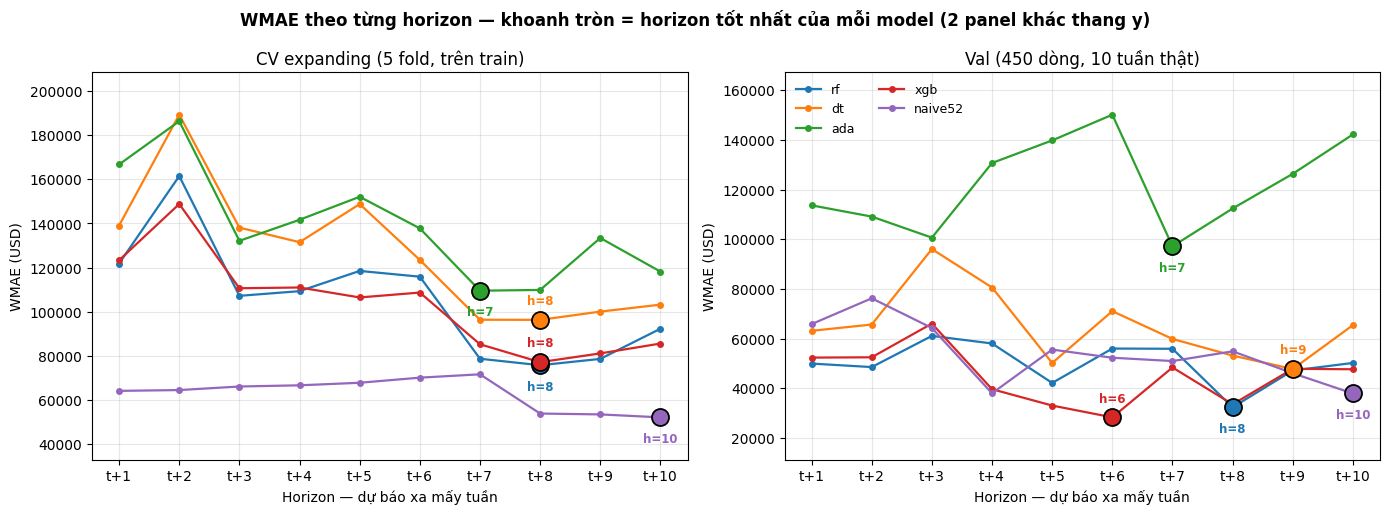

cv                               val                       
        h tốt nhất WMAE (USD) % so TB 10h h tốt nhất WMAE (USD) % so TB 10h
rf             t+8     75,707      -28.5%        t+8     32,284      -35.6%
dt             t+8     96,272      -23.9%        t+9     47,698      -26.9%
ada            t+7    109,498      -21.1%        t+7     97,144      -20.5%
xgb            t+8     77,102      -25.7%        t+6     28,234      -37.1%
naive52       t+10     52,081      -17.3%       t+10     37,849      -30.1%

In [6]:
LBL = {"mae": "MAE (USD)", "rmse": "RMSE (USD)", "wape": "WAPE (%)", "wmae": "WMAE (USD)"}
HS  = np.arange(1, HZ + 1)
SET = (("cv", "CV expanding (5 fold, trên train)"), ("val", "Val (450 dòng, 10 tuần thật)"))

for k in METRICS:
    s   = 100 if k == "wape" else 1
    fmt = "{:.2f}" if k == "wape" else "{:,.0f}"
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
    best = {m: {} for m in ORDER}

    for ax, (pfx, ttl) in zip(axes, SET):
        for i, m in enumerate(ORDER):
            v = results.loc[m, f"{pfx}_{k}"].reindex(HS) * s
            ln, = ax.plot(HS, v.values, "o-", ms=4, lw=1.6, label=m)
            b = int(v.idxmin())
            ax.scatter([b], [v[b]], s=150, color=ln.get_color(), edgecolor="black", lw=1.3, zorder=5)
            # so le trên/dưới để nhãn h= của 2 model cùng đỉnh 1 horizon không đè nhau
            ax.annotate(f"h={b}", (b, v[b]), textcoords="offset points",
                        xytext=(0, -18 if i % 2 == 0 else 11),
                        ha="center", fontsize=8.5, fontweight="bold", color=ln.get_color())
            best[m][pfx] = (b, v[b], v[b] / v.mean() - 1)
        ax.set_xticks(HS, [f"t+{h}" for h in HS])
        ax.set_xlabel("Horizon — dự báo xa mấy tuần")
        ax.set_ylabel(LBL[k])
        ax.set_title(ttl)
        ax.grid(alpha=0.3)
        ax.margins(y=0.14)

    axes[1].legend(frameon=False, ncol=2, fontsize=9)
    fig.suptitle(f"{k.upper()} theo từng horizon — khoanh tròn = horizon tốt nhất của mỗi model"
                 " (2 panel khác thang y)", fontweight="bold")
    plt.tight_layout()
    plt.show()

    rows = {}
    for m, r in best.items():
        row = {}
        for p, (b, v, d) in r.items():
            row[(p, "h tốt nhất")] = f"t+{b}"
            row[(p, LBL[k])] = fmt.format(v)
            row[(p, "% so TB 10h")] = f"{d:+.1%}"
        rows[m] = row
    tb = pd.DataFrame(rows).T.loc[ORDER]
    tb.columns = pd.MultiIndex.from_tuples(tb.columns)
    display(tb)

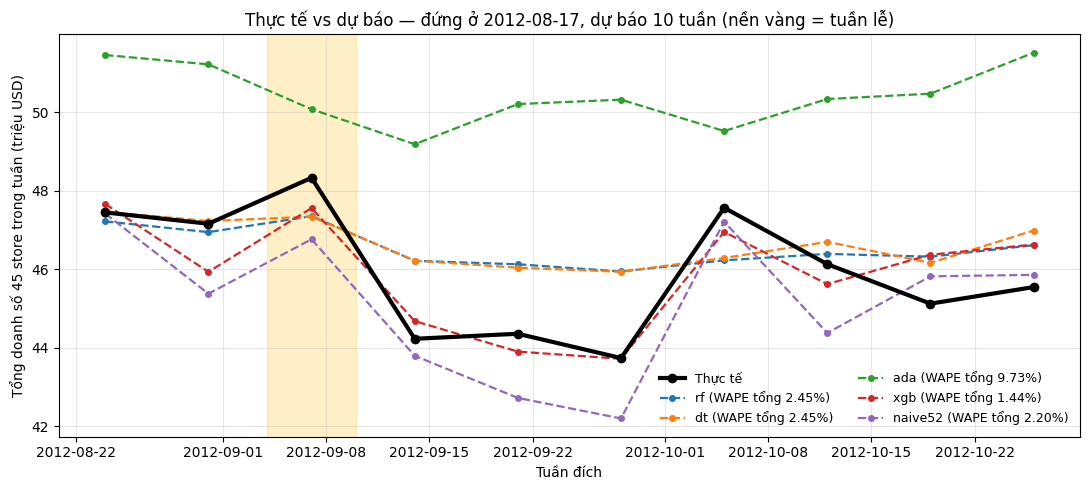

WAPE trong chú thích là WAPE của ĐƯỜNG TỔNG 45 store — nhỏ hơn nhiều WAPE cấp store ở bảng
`overall` (vd xgb: tổng 1.39% vs cấp store 4.40%), vì sai số thừa/thiếu giữa các store bù nhau khi cộng.


In [7]:
allp = pd.concat(PREDS.values(), ignore_index=True)
wide = allp.pivot_table(index="target_Date", columns="model", values="y_pred", aggfunc="sum")[ORDER]
truth = allp[allp.model == "rf"].groupby("target_Date")["y_true"].sum()
hol_dates = [d for d in wide.index if cal.get(d, 0) == 1]

fig, ax = plt.subplots(figsize=(11, 5))
for d in hol_dates:
    ax.axvspan(d - pd.Timedelta(days=3), d + pd.Timedelta(days=3), color="#FFC220", alpha=0.25)
ax.plot(truth.index, truth / 1e6, "o-", lw=3, color="black", label="Thực tế", zorder=5)
for m in ORDER:
    w = sc(truth, wide[m], [cal.get(d, 0) for d in wide.index])["wape"]
    ax.plot(wide.index, wide[m] / 1e6, "o--", lw=1.6, ms=4, label=f"{m} (WAPE tổng {w:.2%})")

ax.set_xlabel("Tuần đích")
ax.set_ylabel("Tổng doanh số 45 store trong tuần (triệu USD)")
ax.set_title(f"Thực tế vs dự báo — đứng ở {T.date()}, dự báo 10 tuần (nền vàng = tuần lễ)")
ax.legend(frameon=False, ncol=2, fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("WAPE trong chú thích là WAPE của ĐƯỜNG TỔNG 45 store — nhỏ hơn nhiều WAPE cấp store ở bảng")
print("`overall` (vd xgb: tổng 1.39% vs cấp store 4.40%), vì sai số thừa/thiếu giữa các store bù nhau khi cộng.")

In [8]:
import joblib
import os

os.makedirs("models", exist_ok=True)
joblib.dump(xgboost_models, "models/xgb_direct_models.joblib")
joblib.dump(rf_models, "models/rf_direct_models.joblib")
joblib.dump(dt_models, "models/dt_direct_models.joblib")
joblib.dump(ada_models, "models/ada_direct_models.joblib")

['models/ada_direct_models.joblib']